#### Exercise 6 - Starter - Placebo Testing Difference-in-Differences 

Your company sells dog toys and cat toys (possibly among other items). Your company hired a professional photographer who overhauled the product photos for dog toys. Starting on Oct 1 2024, all customers reaching the website and observing the dog toy products observed the new photos. 

Three months later, you are tasked to evaluate the impact of the professional photos on revenue to determine if it is worth making the investment for additional products. 

We have generated time series panel data for monthly revenue from dog toys and cat toys throughout 2023 and 2024. Revenue is driven by a baseline (separate for each product), seasonality, a general holiday season bump, a 'ground truth' effect for the professional photos, and random noise. 

The benefit of generating data this way is that we know what the true effect is and we can test how well the model performs under various circumstances.

In [1]:
import pandas as pd
import numpy as np
import statsmodels.formula.api as smf 
import seaborn as sns
import matplotlib.pyplot as plt

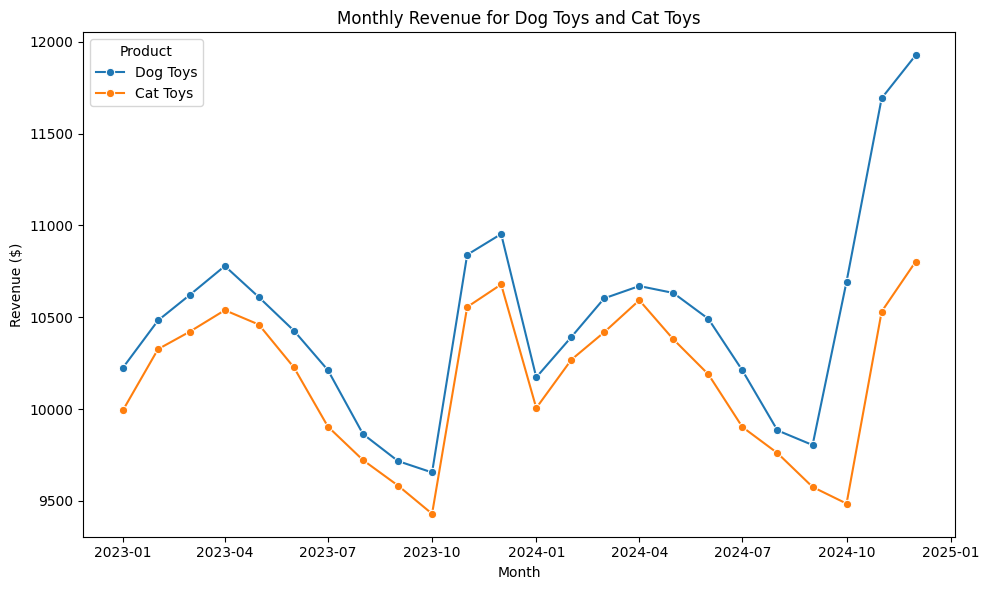

In [2]:
# Set random seed for reproducibility
np.random.seed(42)

# Parameters
n_months = 24
products = ["Dog Toys", "Cat Toys"]
months = pd.date_range(start="2023-01-01", periods=n_months, freq='MS')

# Marketing event date
event_date = pd.to_datetime('2024-10-01')
model_start_date = '2024-01-01'
model_end_date = '2025-01-01' 


# Create base dataframe
df = pd.DataFrame([(month, product) for month in months for product in products],
                  columns=["Month", "Product"])

# Add month number for seasonality
df["Month_Num"] = df["Month"].dt.month

# Seasonality: smooth wave + December holiday bump
df["Seasonality"] = 500 * np.sin((df["Month_Num"] - 1) / 12 * 2 * np.pi)
df["HolidayBump"] = np.where(df["Month_Num"] >= 11, 1000, 0)

# Add randomness and slight product-level difference
df["BaseRevenue"] = 10000
df["ProductGapBaseline"] = df["Product"].map({"Dog Toys": 200, "Cat Toys": 0})
df["Noise"] = np.random.normal(0, 50, size=len(df))


#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%
#%%%%%  This is the ground-truth effect of the treatment: 
#%%%%%  an extra $1000 monthly revenue for dog toys in Q4 2024 
#%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%%

df['BetterPhotos'] = np.where((df['Product']=='Dog Toys') & (df['Month'] >= event_date), 1000, 0)

# Final revenue
df["Revenue"] = (
    df["BaseRevenue"]
    + df["ProductGapBaseline"]
    + df["Seasonality"]
    + df["HolidayBump"]
    + df["BetterPhotos"]
    + df["Noise"]
)

# Visualize the time series
plt.figure(figsize=(10, 6))
sns.lineplot(data=df, x="Month", y="Revenue", hue="Product", marker="o")
plt.title("Monthly Revenue for Dog Toys and Cat Toys")
plt.ylabel("Revenue ($)")
plt.tight_layout()
plt.show()

# Final output DataFrame
df = df[["Month", "Product", "Revenue"]]

One way to test any of the causal inference models is to estimate an identical model on pre-treatment data. In this case, you have some choices: you could estimate the model using 2023 data only again using Q4 as the placebo treatment event period. Alternatively, you can choose to use more recent data: e.g. treating Q3 2024 as the placebo and maintaining a one-year preperiod.  

For this exercise, you need just one placebo test. In practice, you can improve confidence in the precision of these models by estimating many placebo tests over a wide range of dates (or even switching up treated units!). 


In [4]:
placebo_event_date = '2024-07-01' 
placebo_start_date = '2023-07-01'
placebo_end_date = '2024-10-01'

# TO-DO: Estimate the difference-in-differences model using data shifted back prior to the treatment data
subset=df[(df['Month'] >= placebo_start_date) & (df['Month']<placebo_end_date)].copy()

subset['treated']=(subset['Product'] == 'Dog Toys').astype(int)
subset['post']=(subset['Month']>=placebo_event_date).astype(int)
subset['post_treated']=subset['treated']*subset['post']

formula = 'Revenue~treated+post+post_treated'
model = smf.ols(formula=formula, data=subset).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.207
Model:                            OLS   Adj. R-squared:                  0.115
Method:                 Least Squares   F-statistic:                     2.259
Date:                Sat, 29 Nov 2025   Prob (F-statistic):              0.105
Time:                        20:43:46   Log-Likelihood:                -219.86
No. Observations:                  30   AIC:                             447.7
Df Residuals:                      26   BIC:                             453.3
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.014e+04    114.305     88.745   

In [6]:
### what's the estimated monthly effect during the placebo period?
print(f"Estimated Monthly Effect:{model.params['post_treated']:.2f}")


Estimated Monthly Effect:13.94


In [8]:
# What if you chose an alternative date (e.g. same quarter, prior year)?

placebo_event_date = '2023-10-01' 
placebo_start_date = '2023-01-01'
placebo_end_date = '2024-01-01'

# TO-DO: Estimate the difference-in-differences model using data shifted back one year
subset=df[(df['Month']>=placebo_start_date)&(df['Month']<placebo_end_date)].copy()
subset['treated']=(subset['Product']=='Dog Toys').astype(int)
subset['post']=(subset['Month']>=placebo_event_date).astype(int)
subset['post_treated']=subset['treated']*subset['post']

formula='Revenue~treated+post+post_treated'
model=smf.ols(formula=formula, data=subset).fit()
print(model.summary())


                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.080
Model:                            OLS   Adj. R-squared:                 -0.058
Method:                 Least Squares   F-statistic:                    0.5810
Date:                Sat, 29 Nov 2025   Prob (F-statistic):              0.634
Time:                        20:47:18   Log-Likelihood:                -178.17
No. Observations:                  24   AIC:                             364.3
Df Residuals:                      20   BIC:                             369.1
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
Intercept     1.013e+04    148.015     68.442   